# Ensemble Learning: Gradient Boosting — Step-by-Step from Scratch

---

## Introduction

**Gradient Boosting** is a sequential ensemble method that builds an additive model by fitting each new tree to the **residuals** (errors) of the current ensemble. It can be understood as gradient descent in function space: each tree is a step in the direction that most reduces the loss.

### Gradient Boosting vs. AdaBoost

| Property | AdaBoost | Gradient Boosting |
|---|---|---|
| Focus mechanism | Reweights misclassified samples | Fits new tree to residuals directly |
| Loss function | Exponential | Any differentiable loss (MSE, MAE, etc.) |
| Base learner depth | Depth-1 stump | Typically depth 3–5 |
| Update rule | Sample weight update | Residual fitting |
| Flexibility | Lower | Higher |

### The Algorithm (Regression)

| Step | Action |
|---|---|
| 1 | Initialize prediction as the **mean** of the target: $\hat{y}^{(0)} = \bar{y}$ |
| 2 | Compute residuals: $r_i = y_i - \hat{y}_i^{(t-1)}$ |
| 3 | Fit a new regression tree to the residuals |
| 4 | Update prediction: $\hat{y}^{(t)} = \hat{y}^{(t-1)} + \eta \cdot h_t(x)$ |
| 5 | Repeat steps 2–4 for $T$ rounds |

Where $\eta$ is the **learning rate** and $h_t$ is the $t$-th tree. A smaller learning rate requires more trees but produces smoother, more generalizable models.

This notebook implements these steps **manually** on a 1D synthetic dataset — $y = 3x^2 + \epsilon$ — making each residual, tree fit, and prediction update fully visible before demonstrating the full recursive implementation.

---

## 1. Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import r2_score, mean_squared_error

import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

---

## 2. Synthetic Dataset

The target function is $y = 3x^2 + \epsilon$, a parabola with small Gaussian noise. The 1D design makes it easy to visualize how the ensemble prediction curve evolves with each boosting round.

In [2]:
np.random.seed(42)
X = np.random.rand(100, 1) - 0.5       # X in [-0.5, 0.5]
y = 3 * X[:, 0]**2 + 0.05 * np.random.randn(100)

df = pd.DataFrame({'X': X.reshape(100), 'y': y})

# Dense test grid for smooth prediction curves
X_test = np.linspace(-0.5, 0.5, 500).reshape(-1, 1)

print('Dataset shape:', df.shape)
print(f'y range: [{y.min():.3f}, {y.max():.3f}]')

Dataset shape: (100, 2)
y range: [-0.070, 0.760]


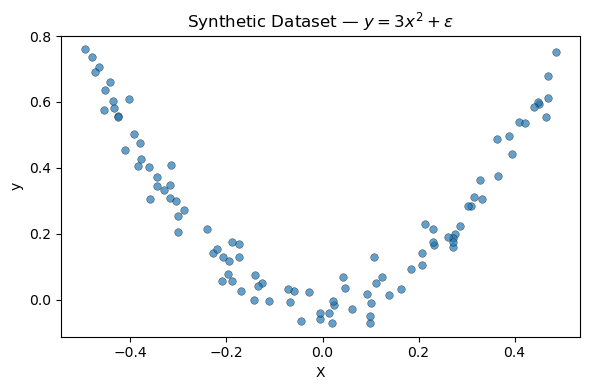

In [3]:
plt.figure(figsize=(6, 4))
plt.scatter(df['X'], df['y'], alpha=0.7, edgecolors='k', linewidths=0.3, s=30)
plt.xlabel('X')
plt.ylabel('y')
plt.title('Synthetic Dataset — $y = 3x^2 + \epsilon$')
plt.tight_layout()
plt.show()

---

## 3. Step 1 — Initialize with the Mean

The ensemble starts with the simplest possible prediction: the **mean of all target values**. This is the constant that minimizes MSE and serves as the baseline from which all subsequent trees improve.

$$\hat{y}^{(0)} = \bar{y} = \frac{1}{N}\sum_{i=1}^N y_i$$

In [4]:
y_mean = df['y'].mean()
df['pred0'] = y_mean

print(f'Initial prediction (mean): {y_mean:.6f}')
print(f'Initial MSE              : {mean_squared_error(df["y"], df["pred0"]):.6f}')

Initial prediction (mean): 0.265458
Initial MSE              : 0.055700


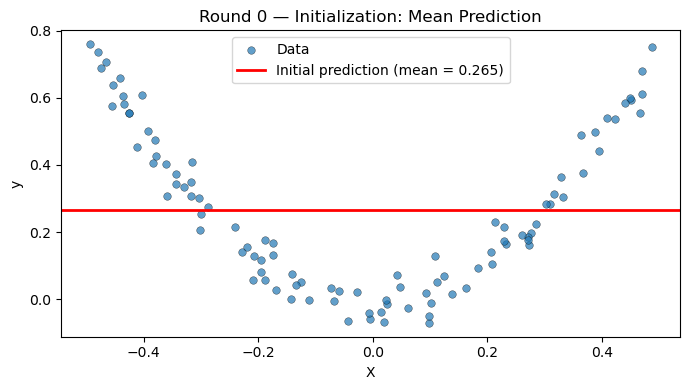

In [5]:
plt.figure(figsize=(7, 4))
plt.scatter(df['X'], df['y'], alpha=0.7, edgecolors='k', linewidths=0.3, s=30, label='Data')
plt.axhline(y_mean, color='red', lw=2, label=f'Initial prediction (mean = {y_mean:.3f})')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Round 0 — Initialization: Mean Prediction')
plt.legend()
plt.tight_layout()
plt.show()

---

## 4. Round 1 — Fit First Tree to Residuals

### Step 2: Compute Residuals

The residuals $r_i^{(1)} = y_i - \hat{y}_i^{(0)}$ represent the error the current ensemble makes on each sample. The next tree is trained to predict these residuals — effectively learning what the current model gets wrong.

In [6]:
df['res1'] = df['y'] - df['pred0']

print('Residuals (first 5 rows):')
print(df[['X', 'y', 'pred0', 'res1']].head())
print(f'\nResidual mean : {df["res1"].mean():.6f}  (should be ~0 since pred0 = mean)')
print(f'Residual std  : {df["res1"].std():.6f}')

Residuals (first 5 rows):
          X         y     pred0      res1
0 -0.125460  0.051573  0.265458 -0.213885
1  0.450714  0.594480  0.265458  0.329021
2  0.231994  0.166052  0.265458 -0.099407
3  0.098658 -0.070178  0.265458 -0.335636
4 -0.343981  0.343986  0.265458  0.078528

Residual mean : 0.000000  (should be ~0 since pred0 = mean)
Residual std  : 0.237198


### Step 3: Fit Tree 1 to Residuals

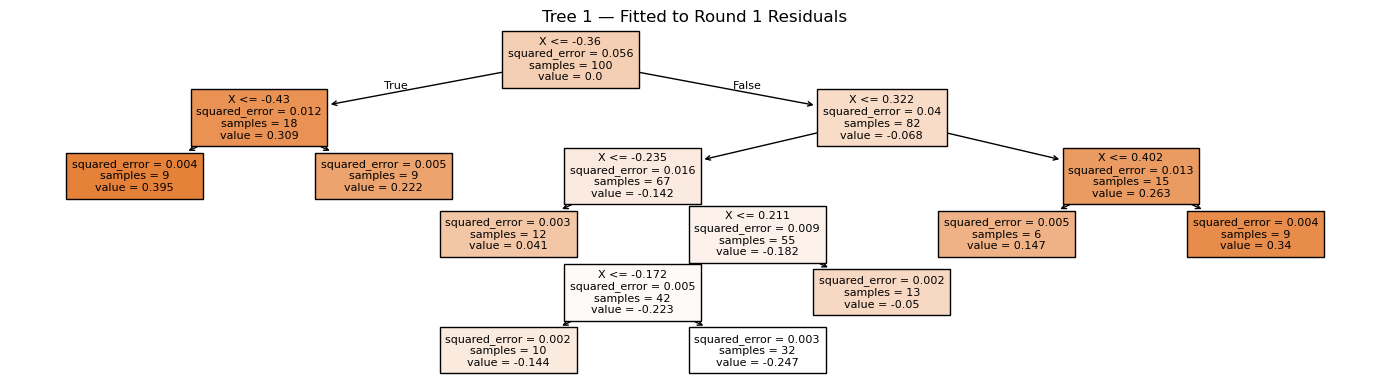

In [7]:
tree1 = DecisionTreeRegressor(max_leaf_nodes=8, random_state=42)
tree1.fit(df[['X']], df['res1'])

plt.figure(figsize=(14, 4))
plot_tree(tree1, feature_names=['X'], filled=True, fontsize=8)
plt.title('Tree 1 — Fitted to Round 1 Residuals')
plt.tight_layout()
plt.show()

### Step 4: Update Prediction

The new ensemble prediction is the initial mean plus the first tree's prediction:

$$\hat{y}^{(1)} = \hat{y}^{(0)} + h_1(x) = \bar{y} + h_1(x)$$

In [8]:
df['pred1'] = df['pred0'] + tree1.predict(df[['X']])
df['res2']  = df['y'] - df['pred1']

r2_round1 = r2_score(df['y'], df['pred1'])
print(f'Round 1 — R²: {r2_round1:.4f}   MSE: {mean_squared_error(df["y"], df["pred1"]):.6f}')

Round 1 — R²: 0.9405   MSE: 0.003315


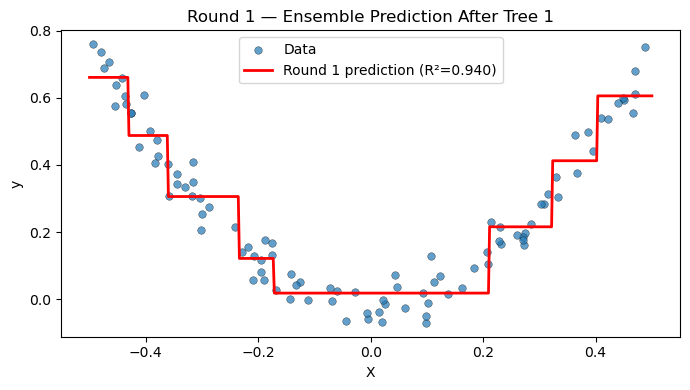

In [9]:
y_pred_round1 = y_mean + tree1.predict(X_test)

plt.figure(figsize=(7, 4))
plt.scatter(df['X'], df['y'], alpha=0.7, edgecolors='k', linewidths=0.3, s=30, label='Data')
plt.plot(X_test, y_pred_round1, 'r', lw=2, label=f'Round 1 prediction (R²={r2_round1:.3f})')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Round 1 — Ensemble Prediction After Tree 1')
plt.legend()
plt.tight_layout()
plt.show()

---

## 5. Round 2 — Fit Second Tree to Updated Residuals

Round 2 residuals $r_i^{(2)} = y_i - \hat{y}_i^{(1)}$ capture what the Round 1 ensemble still gets wrong. Tree 2 is trained on these and added to the ensemble.

In [10]:
tree2 = DecisionTreeRegressor(max_leaf_nodes=8, random_state=42)
tree2.fit(df[['X']], df['res2'])

# Ensemble prediction: mean + tree1 + tree2
y_pred_round2 = y_mean + sum(
    t.predict(X_test) for t in [tree1, tree2]
)

df['pred2'] = y_mean + sum(
    t.predict(df[['X']]) for t in [tree1, tree2]
)
df['res3'] = df['y'] - df['pred2']

r2_round2 = r2_score(df['y'], df['pred2'])
print(f'Round 2 — R²: {r2_round2:.4f}   MSE: {mean_squared_error(df["y"], df["pred2"]):.6f}')

Round 2 — R²: 0.9617   MSE: 0.002132


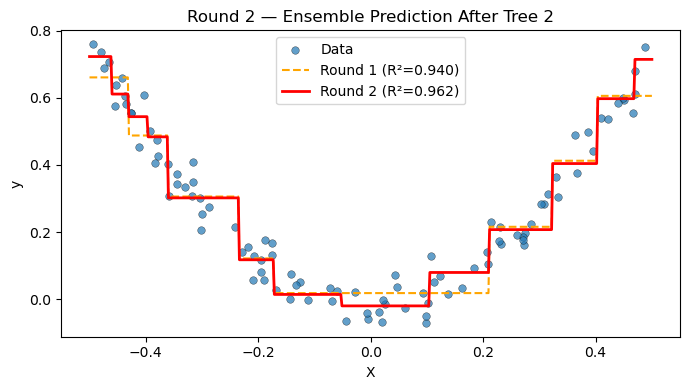

In [11]:
plt.figure(figsize=(7, 4))
plt.scatter(df['X'], df['y'], alpha=0.7, edgecolors='k', linewidths=0.3, s=30, label='Data')
plt.plot(X_test, y_pred_round1, 'orange', lw=1.5, linestyle='--', label=f'Round 1 (R²={r2_round1:.3f})')
plt.plot(X_test, y_pred_round2, 'red',    lw=2,   label=f'Round 2 (R²={r2_round2:.3f})')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Round 2 — Ensemble Prediction After Tree 2')
plt.legend()
plt.tight_layout()
plt.show()

---

## 6. Full Recursive Implementation

The manual two-round process above generalizes naturally into a recursive function. Each call fits a tree to the current residuals, appends it to the ensemble, plots the updated prediction curve, and recurses on the new residuals.

The `learning_rate` ($\eta$) scales each tree's contribution — a value of 1.0 is shown here to make the convergence fast and visible. In practice, smaller values (0.05–0.1) are preferred for better generalization.

In [12]:
def gradient_boost(X, y, n_rounds, lr, _count=1, _trees=[], _y_orig=None):
    """
    Recursive gradient boosting implementation.

    Parameters
    ----------
    X        : Training features (n_samples, n_features)
    y        : Residuals for this round (or original targets on first call)
    n_rounds : Remaining boosting rounds
    lr       : Learning rate — scales each tree's contribution
    """
    if n_rounds == 0:
        return

    # Store original targets on first call
    if _count == 1:
        _y_orig = y.copy()
    else:
        # Update residuals: subtract last tree's prediction
        y = y - _trees[-1].predict(X)

    # Fit new tree to current residuals
    tree = DecisionTreeRegressor(max_depth=5, random_state=42)
    tree.fit(X, y)
    _trees.append(tree)

    # Ensemble prediction on dense test grid
    x_grid = np.linspace(-0.5, 0.5, 500).reshape(-1, 1)
    y_pred = sum(lr * t.predict(x_grid) for t in _trees)

    r2 = r2_score(_y_orig, sum(lr * t.predict(X) for t in _trees))

    plt.figure(figsize=(7, 4))
    plt.plot(x_grid, y_pred, lw=2, color='steelblue', label=f'Ensemble prediction')
    plt.scatter(X[:, 0], _y_orig, color='tomato', s=20, alpha=0.7, label='Data')
    plt.xlabel('X')
    plt.ylabel('y')
    plt.title(f'Round {_count}  |  Trees: {len(_trees)}  |  R² = {r2:.4f}')
    plt.legend(fontsize=9)
    plt.tight_layout()
    plt.show()

    gradient_boost(X, y, n_rounds - 1, lr, _count + 1, _trees, _y_orig)

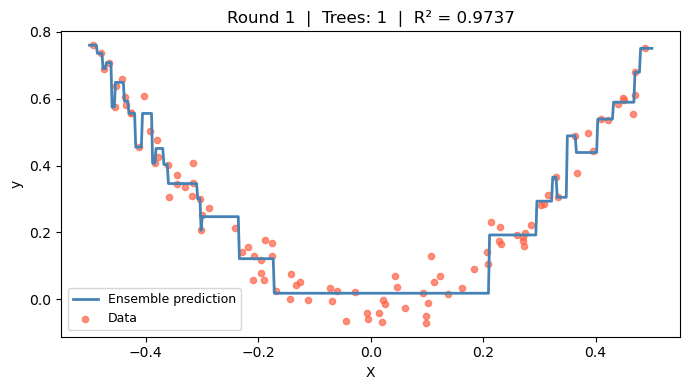

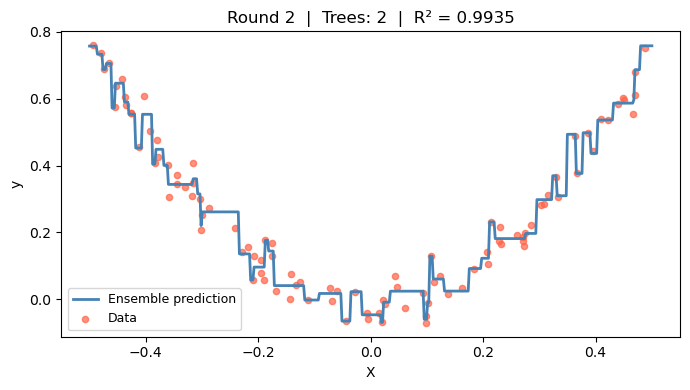

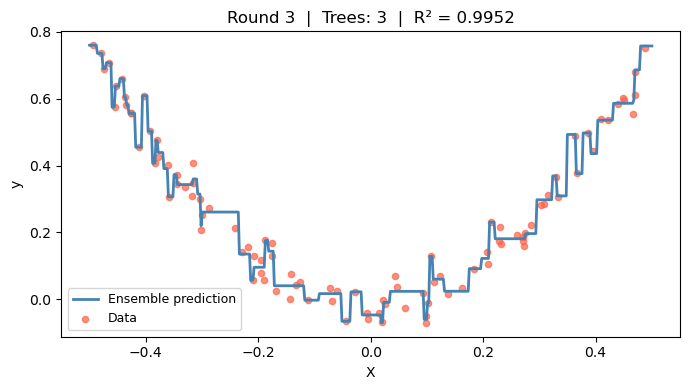

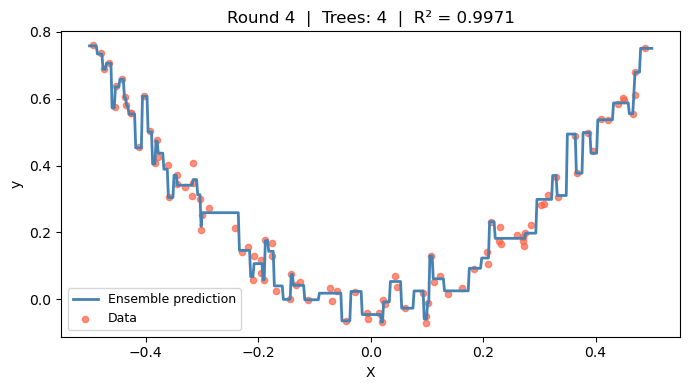

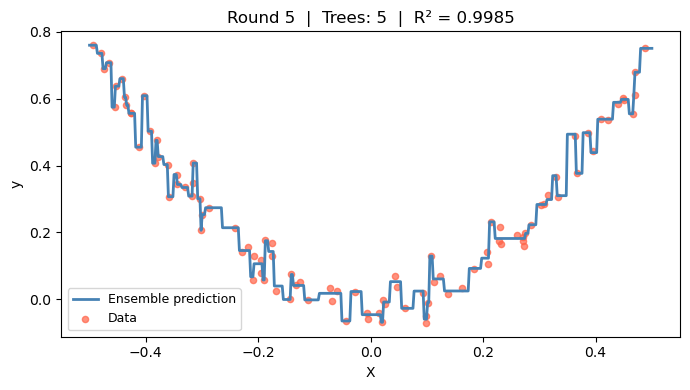

In [13]:
np.random.seed(42)
X = np.random.rand(100, 1) - 0.5
y = 3 * X[:, 0]**2 + 0.05 * np.random.randn(100)

gradient_boost(X, y, n_rounds=5, lr=1.0)

---

## 7. Residual Decay Across Rounds

Each boosting round should reduce the magnitude of residuals. The plot below shows how the residual standard deviation decreases as the ensemble grows, confirming that each new tree is capturing real signal rather than fitting noise.

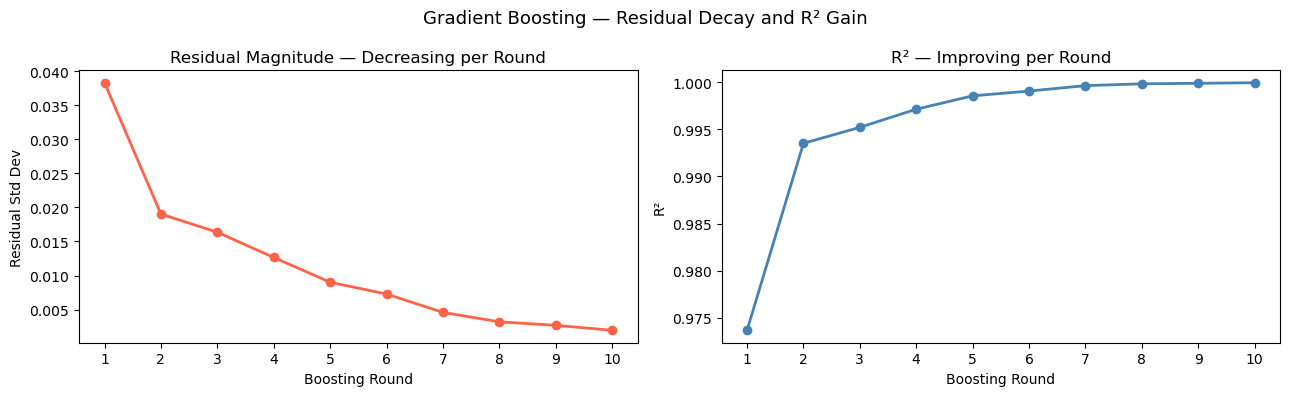

Round-by-Round Summary:
-----------------------------------
Round  1  Residual Std: 0.03828   R²: 0.97369
Round  2  Residual Std: 0.01902   R²: 0.99351
Round  3  Residual Std: 0.01635   R²: 0.99520
Round  4  Residual Std: 0.01266   R²: 0.99712
Round  5  Residual Std: 0.00902   R²: 0.99854
Round  6  Residual Std: 0.00729   R²: 0.99905
Round  7  Residual Std: 0.00460   R²: 0.99962
Round  8  Residual Std: 0.00322   R²: 0.99981
Round  9  Residual Std: 0.00271   R²: 0.99987
Round 10  Residual Std: 0.00197   R²: 0.99993


In [14]:
np.random.seed(42)
X = np.random.rand(100, 1) - 0.5
y_arr = 3 * X[:, 0]**2 + 0.05 * np.random.randn(100)

residuals_std = []
r2_scores     = []
trees         = []
current_res   = y_arr.copy()

for round_idx in range(1, 11):
    tree = DecisionTreeRegressor(max_depth=5, random_state=42)
    tree.fit(X, current_res)
    trees.append(tree)

    y_pred = sum(t.predict(X) for t in trees)
    current_res = y_arr - y_pred

    residuals_std.append(current_res.std())
    r2_scores.append(r2_score(y_arr, y_pred))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(range(1, 11), residuals_std, 'o-', color='tomato', lw=2)
axes[0].set_xlabel('Boosting Round')
axes[0].set_ylabel('Residual Std Dev')
axes[0].set_title('Residual Magnitude — Decreasing per Round')
axes[0].set_xticks(range(1, 11))

axes[1].plot(range(1, 11), r2_scores, 'o-', color='steelblue', lw=2)
axes[1].set_xlabel('Boosting Round')
axes[1].set_ylabel('R²')
axes[1].set_title('R² — Improving per Round')
axes[1].set_xticks(range(1, 11))

plt.suptitle('Gradient Boosting — Residual Decay and R² Gain', fontsize=13)
plt.tight_layout()
plt.show()

print('Round-by-Round Summary:')
print('-' * 35)
for i, (std, r2) in enumerate(zip(residuals_std, r2_scores), 1):
    print(f'Round {i:2d}  Residual Std: {std:.5f}   R²: {r2:.5f}')

---

## Conclusion

This notebook implemented Gradient Boosting for regression from scratch on the synthetic parabola dataset $y = 3x^2 + \epsilon$, making every residual computation, tree fit, and prediction update fully explicit.

**Key findings:**

- **Round 0** — the initial mean prediction is a flat line with high residuals. The R² is near zero since no structure has been learned yet.
- **Round 1** — Tree 1 fits the residuals and immediately captures the broad parabolic shape. R² jumps significantly after just one tree.
- **Round 2** — Tree 2 fits the remaining residuals, refining the boundary regions where Round 1 was still inaccurate. The prediction curve tightens around the data.
- The **recursive implementation** shows how this process scales cleanly: each new tree sees a progressively simpler residual pattern, and the ensemble converges toward the true function.
- The **residual decay plot** confirms that residual standard deviation decreases monotonically with each round and R² improves — the ensemble is learning signal, not overfitting noise.

**Takeaways:**

- The core insight of Gradient Boosting is that fitting a new model to residuals is equivalent to taking a gradient step in function space to minimize MSE. This generalizes to any differentiable loss function.
- `learning_rate=1.0` is used here for fast, visible convergence. In practice, `lr=0.05–0.1` with more trees produces smoother models that generalize better.
- The `max_depth` of each base tree controls the interaction order captured per round — deeper trees can overfit, while stumps may underfit on complex patterns.
- `sklearn.ensemble.GradientBoostingRegressor` and `GradientBoostingClassifier` automate everything shown here, adding subsampling, regularization, and efficient tree growing. **XGBoost** and **LightGBM** further optimize with second-order gradients and histogram-based splits.